In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt

In [181]:
lake='neuchatel'
base_folder = rf'/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/{lake}_100m_2025'


In [182]:
bin_folder = os.path.join(base_folder, 'binary_data')

In [183]:
base_output_folder = rf"/storage/alplakes_test/{lake}_100m_2025"
output_folder = os.path.join(base_output_folder, 'wind_analysis')
os.makedirs(output_folder, exist_ok=True)

# Import xarray wind

In [184]:
ds = xr.open_dataset(os.path.join(bin_folder, 'wind.nc'))

In [185]:
ds = ds.sel(time=slice('2025-07-01', '2025-08-01'))

# Print wind rose

In [45]:
rose_direction = ds.direction.values.flatten()
rose_speed = ds.speed.values.flatten()

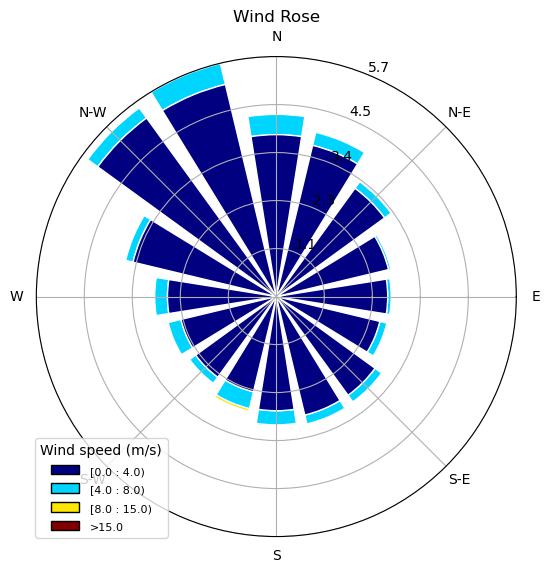

In [26]:
from windrose import WindroseAxes
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig = plt.figure(figsize=(6, 6))

ax = WindroseAxes.from_ax(fig=fig)

ax.bar(
    rose_direction,
    rose_speed,
    bins=[0, 4, 8, 15],
    normed=True,
    opening=0.8,
    edgecolor='white',
    cmap=cm.jet
)

ax.set_legend(title="Wind speed (m/s)")

plt.title("Wind Rose")
plt.show()

# Average wind

In [27]:
import sys
sys.path.append('..//')
from utils_plot import plot_colors
import matplotlib.dates as mdates

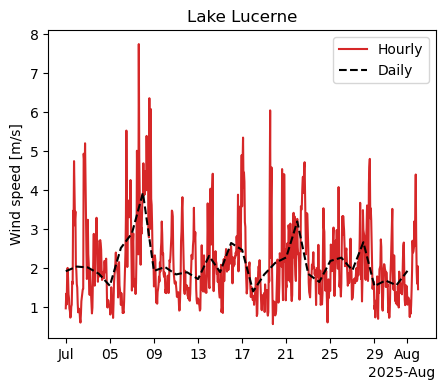

In [46]:
fig, ax = plt.subplots(figsize=(5, 4))
ds.speed.mean(dim=['x', 'y']).plot(c=plot_colors.wind_color, label='Hourly')
ds.speed.mean(dim=['x', 'y']).resample(time='d').mean().plot(c='black', ls='--', label='Daily')
# Labels
ax.set_xlabel('')
ax.set_ylabel("Wind speed [m/s]")
ax.set_title(f"Lake {lake.capitalize()}")
#ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.legend()

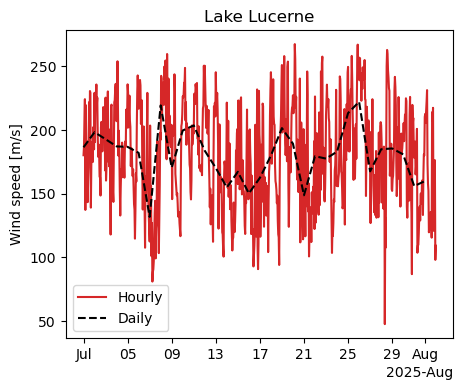

In [47]:
fig, ax = plt.subplots(figsize=(5, 4))
ds.direction.mean(dim=['x', 'y']).plot(c=plot_colors.wind_color, label='Hourly')
ds.direction.mean(dim=['x', 'y']).resample(time='d').mean().plot(c='black', ls='--', label='Daily')
# Labels
ax.set_xlabel('')
ax.set_ylabel("Wind speed [m/s]")
ax.set_title(f"Lake {lake.capitalize()}")
#ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.legend()

# Print wind map

In [48]:
def print_wind(i_time, ds, subsetting_factor, arrow_scale):
    fig = plt.figure(figsize=(8,8))
    ds.speed.isel(time=i_time).plot()

    X_trimmed = ds.x.values[::subsetting_factor]
    Y_trimmed = ds.y.values[::subsetting_factor]
    U_trimmed = ds.u10.isel(time=i_time).values[::subsetting_factor,::subsetting_factor]
    V_trimmed = ds.v10.isel(time=i_time).values[::subsetting_factor,::subsetting_factor]
    plt.quiver(X_trimmed, Y_trimmed, U_trimmed, V_trimmed, scale=arrow_scale)

    plt.title(ds.time.isel(time=i_time).values)

    return fig

In [49]:
wind_map_output_folder = os.path.join(output_folder, 'wind_map')
os.makedirs(wind_map_output_folder, exist_ok=True)

In [57]:
subsetting_factor = 3
arrow_scale = 300

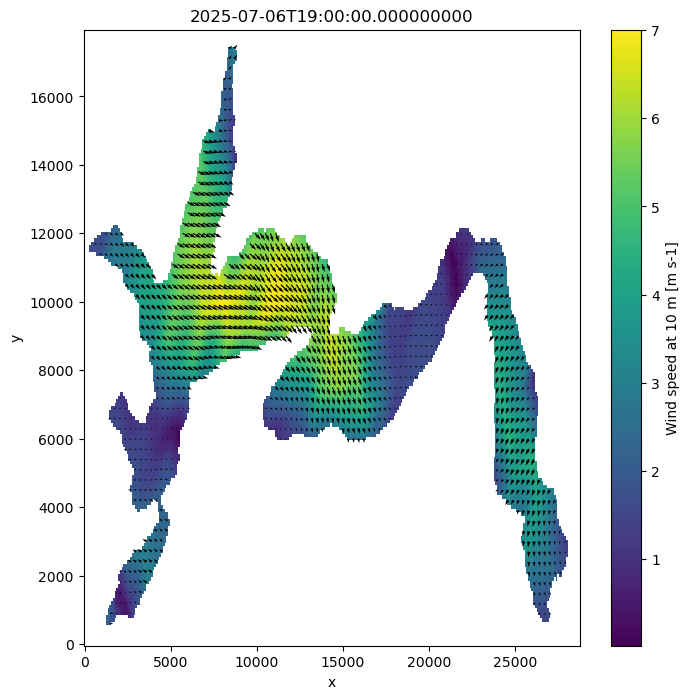

In [58]:
fig=print_wind(139, ds, subsetting_factor, arrow_scale)

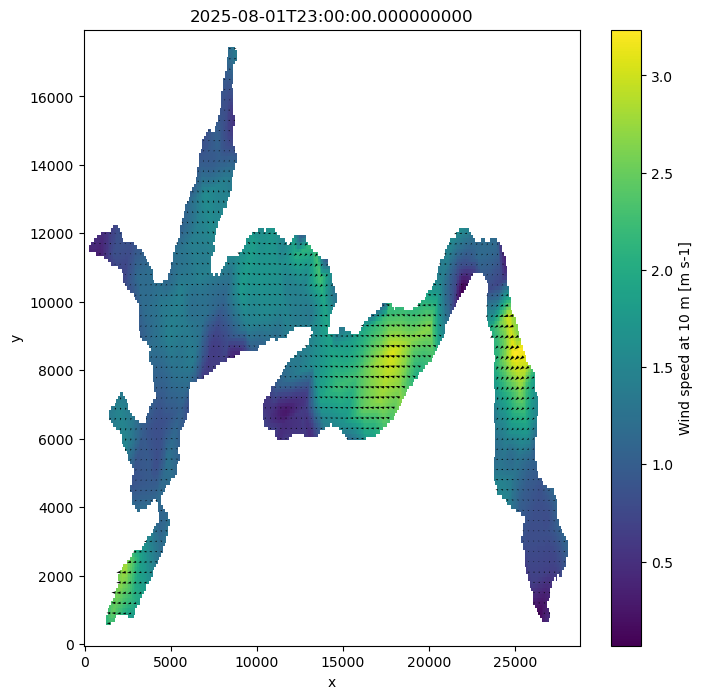

In [59]:
for i_time in range(len(ds.time.values)):
    plt.close('all')
    fig = print_wind(i_time, ds, subsetting_factor, arrow_scale)
    fig.savefig(os.path.join(wind_map_output_folder, f'{str(ds.time.isel(time=i_time).values).replace(":", "").replace(".000000000", "")}.png'))

# Get moving average

In [11]:
ds_5h = ds.rolling(time=5, min_periods=1).mean()

In [12]:
ds_24h = ds.rolling(time=24, min_periods=1).mean()

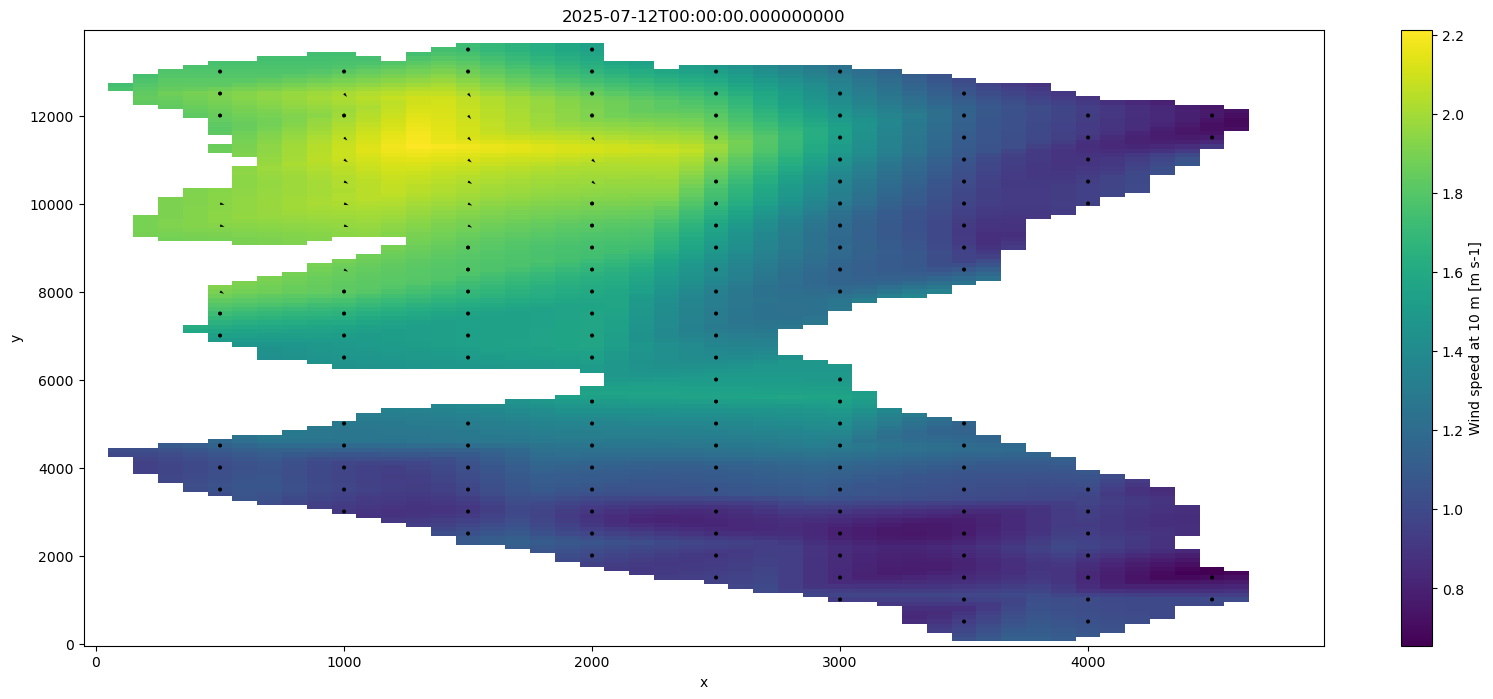

In [13]:
fig=print_wind(3192, ds_5h, subsetting_factor, arrow_scale)


# Get curl

In [186]:
dvdx = ds.v10.differentiate("x")
dudy = ds.u10.differentiate("y")

vorticity = dvdx - dudy

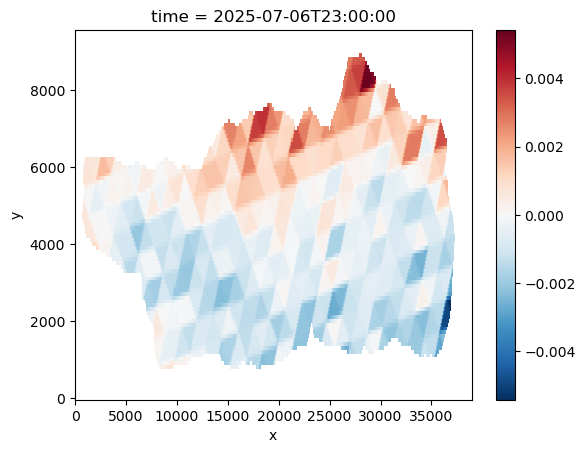

In [187]:
vorticity.isel(time=143).plot()


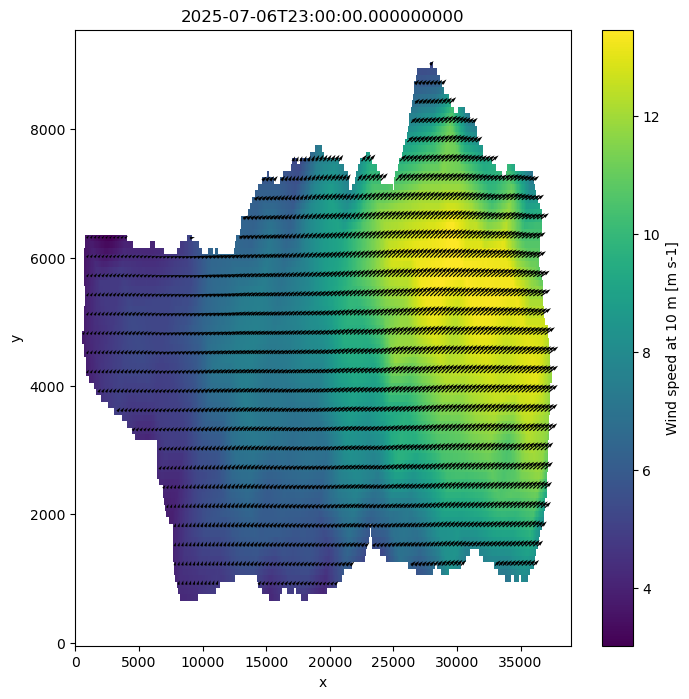

In [188]:
fig=print_wind(143, ds, 3, 500)

Text(0.5, 1.0, 'Lake Neuchatel')

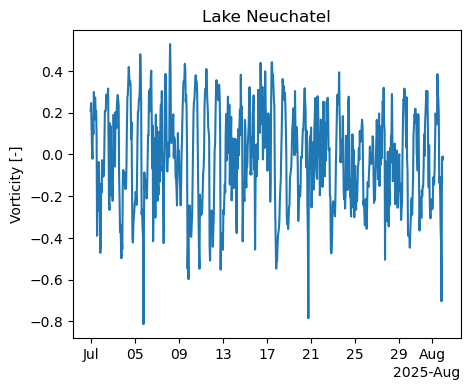

In [189]:
fig, ax = plt.subplots(figsize=(5, 4))

(vorticity*1000).mean(dim=['x','y']).plot()

# Labels
ax.set_xlabel('')
ax.set_ylabel("Vorticity [-]")
ax.set_title(f"Lake {lake.capitalize()}")
#ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))


In [190]:
np.abs(vorticity.mean(dim=['x','y'])).mean().values*1000

np.float64(0.19215475195123277)